<a href="https://colab.research.google.com/github/fuertesnatwit/Individual-Data-Science-Project/blob/main/individualProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [ ]:
#importing data

file_path = "/content/Womens Clothing Reviews Data.csv"
df = pd.read_csv(file_path)
df.columns

Index(['Product ID', 'Category', 'Subcategory1', 'SubCategory2', 'Location',
       'Channel', 'Customer Age', 'Review Title', 'Review Text', 'Rating',
       'Recommend Flag'],
      dtype='object')

#Are certain subcategories more popular with specific age groups?

In [ ]:
#Comparing only data that have a subcategory
df_cleaned = df.dropna(subset=['Subcategory1'])

unique_categories = df_cleaned['Subcategory1'].unique().tolist()
print(unique_categories)


['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend']


In [ ]:
df_cleaned['Age Group'] = pd.cut(df['Customer Age'],
                         bins=[18,25,35,45,55,65,100],
                         labels=['18-25','26-35','36-45','46-55','56-65','65+'])

/tmp/ipykernel_628/1237599820.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Age Group'] = pd.cut(df['Customer Age'],


In [ ]:
popularity = df_cleaned.groupby(['Age Group','Subcategory1']).size()
popularity

/tmp/ipykernel_628/167073777.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  popularity = df_cleaned.groupby(['Age Group','Subcategory1']).size()


Age Group  Subcategory1
18-25      Bottoms          181
           Dresses          355
           Intimate         115
           Jackets           54
           Tops             502
           Trend             10
26-35      Bottoms          885
           Dresses         1737
           Intimate         531
           Jackets          259
           Tops            2321
           Trend             18
36-45      Bottoms         1287
           Dresses         2011
           Intimate         508
           Jackets          289
           Tops            3247
           Trend             44
46-55      Bottoms          798
           Dresses         1241
           Intimate         342
           Jackets          201
           Tops            2297
           Trend             25
56-65      Bottoms          489
           Dresses          723
           Intimate         157
           Jackets          159
           Tops            1508
           Trend             14
65+        Bottoms          158
           Dresses          250
           Intimate          82
           Jackets           70
           Tops             592
           Trend              8
dtype: int64

#Are customers on mobile more likely to leave a review/longer review than web customers?

In [ ]:
mobile_users = df[df['Channel'] == 'Mobile']
web_users = df[df['Channel'] == 'Web']

In [ ]:
null_web_count = web_users[web_users['Review Text'].isnull()]['Product ID'].count()
null_mobile_count = mobile_users[mobile_users['Review Text'].isnull()]['Product ID'].count()
print(null_web_count/web_users['Product ID'].count())
print(null_mobile_count/mobile_users['Product ID'].count())

0.03585364058013694
0.03615066141573261


In [ ]:
print(mobile_users['Review Text'].str.len().median())
print(web_users['Review Text'].str.len().median())
unique_values, counts = np.unique(web_users['Review Text'].str.len(), return_counts=True)

# Find the index of the maximum count
max_count_index = np.argmax(counts)

# Get the mode value using that index
mode_value = unique_values[max_count_index]

301.0
302.0
The mode is: 500.0
1775


(array([ 150.,  695.,  963.,  994., 1084., 1022.,  858.,  738.,  632.,
        2409.]),
 array([  9. ,  58.7, 108.4, 158.1, 207.8, 257.5, 307.2, 356.9, 406.6,
        456.3, 506. ]),
 <BarContainer object of 10 artists>)

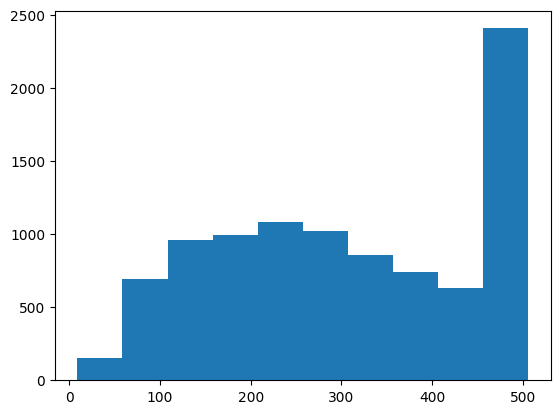

In [ ]:
plt.hist(mobile_users['Review Text'].str.len(), density= False)

In [ ]:
df.columns

Index(['Product ID', 'Category', 'Subcategory1', 'SubCategory2', 'Location',
       'Channel', 'Customer Age', 'Review Title', 'Review Text', 'Rating',
       'Recommend Flag'],
      dtype='object')

(array([ 257.,  984., 1276., 1478., 1415., 1337., 1179., 1059.,  839.,
        3272.]),
 array([ 11. ,  60.7, 110.4, 160.1, 209.8, 259.5, 309.2, 358.9, 408.6,
        458.3, 508. ]),
 <BarContainer object of 10 artists>)

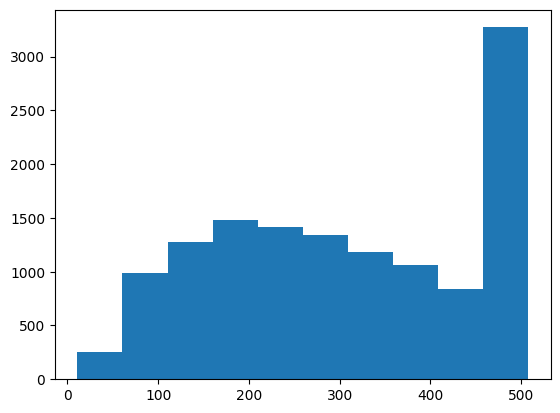

In [ ]:
plt.hist(web_users['Review Text'].str.len(), density= False)

#Other Work

In [ ]:
x=np.array([1,2,3,4])
y=np.array([7,9,11,13])

x_mean = np.mean(x)
y_mean = np.mean(y)
m = np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
b= y_mean-m *x_mean

In [ ]:
from sklearn.linear_model import LinearRegression
X = x[:,np.newaxis]
model = LinearRegression()
model.fit(X,y)
model.coef_, model.intercept_

In [ ]:
x = np.array([1,2,3,4])
y = np.array([1,4,9,16])

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias = False)
X_poly = poly.fit_transform(x[:,None])
model = LinearRegression()
model.fit(X_poly,y)